<a href="https://colab.research.google.com/github/Prathamesh-kadam/SN2025qe-/blob/main/2025qe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Combining data of GIT and HCT**

In [3]:
import pandas as pd
import numpy as np

# Define exact column names as they appear in original files
git_cols = ['JD', 'g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez']
hct_cols = ['JD', 'u', 'eu', 'g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez']

# Read files with proper column names
git_df = pd.read_csv('/content/drive/MyDrive/2025qe/git_sub_mag4_vishwajeet.txt',
                     sep=r'\s+', header=None, names=git_cols)

hct_df = pd.read_csv('/content/drive/MyDrive/2025qe/hct_sub_mag2_vishwajeet.txt',
                     sep=r'\s+', header=None, names=hct_cols)

# Add source column
git_df['source'] = 'GIT'
hct_df['source'] = 'HCT'

# Extract only matching columns from HCT (g,eg,r,er,i,ei,z,ez) - ignore u,eu
hct_matched = hct_df[['JD', 'g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez', 'source']].copy()

# Combine GIT first, then matched HCT
combined_df = pd.concat([git_df, hct_matched], ignore_index=True)

# Convert JD to numeric and sort chronologically
combined_df['JD'] = pd.to_numeric(combined_df['JD'], errors='coerce')
combined_df = combined_df.sort_values('JD').reset_index(drop=True)

# Convert photometry columns: INDEF → NaN, keep numeric magnitudes/errors
phot_cols = ['g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez']
for col in phot_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Save combined light curve to CSV
combined_df.to_csv('SN2025qe_combined.csv', index=False)

# Display results
print("First 15 rows:")
print(combined_df.head(15))
print(f"\nCombined shape: {combined_df.shape}")
print("\nColumns:", combined_df.columns.tolist())
print("\nSample g,r,i bands by source:")
print(combined_df.groupby('source')[['g', 'r', 'i']].head(2))
print("\nFinal columns: JD, g, eg, r, er, i, ei, z, ez, source")


First 15 rows:
           JD      g     eg      r     er      i     ei      z     ez source
0   2460697.2  16.93  0.067  17.06  0.099  17.29  0.052  17.67  0.085    GIT
1   2460699.1  16.61  0.058  16.71  0.130  16.98  0.060    NaN    NaN    GIT
2   2460700.1  16.53  0.050  16.62  0.112  16.85  0.047    NaN    NaN    GIT
3   2460701.1  16.46  0.054  16.53  0.129  16.73  0.046  16.89  0.055    GIT
4   2460702.1  16.43  0.063  16.45  0.124  16.66  0.080  16.88  0.098    GIT
5   2460703.1  16.40  0.015  16.41  0.080  16.68  0.058    NaN    NaN    GIT
6   2460704.3  16.33  0.058  16.36  0.031  16.75  0.045  16.59  0.061    HCT
7   2460706.1  16.41  0.027    NaN    NaN  16.46  0.039    NaN    NaN    GIT
8   2460707.2  16.40  0.113  16.26  0.110  16.49  0.059  16.62  0.067    GIT
9   2460708.1  16.39  0.055    NaN    NaN    NaN    NaN    NaN    NaN    GIT
10  2460709.1    NaN    NaN    NaN    NaN  16.39  0.084    NaN    NaN    GIT
11  2460710.1    NaN    NaN  16.31  0.069  16.39  0.100    Na

**Plotting of GIT Data**

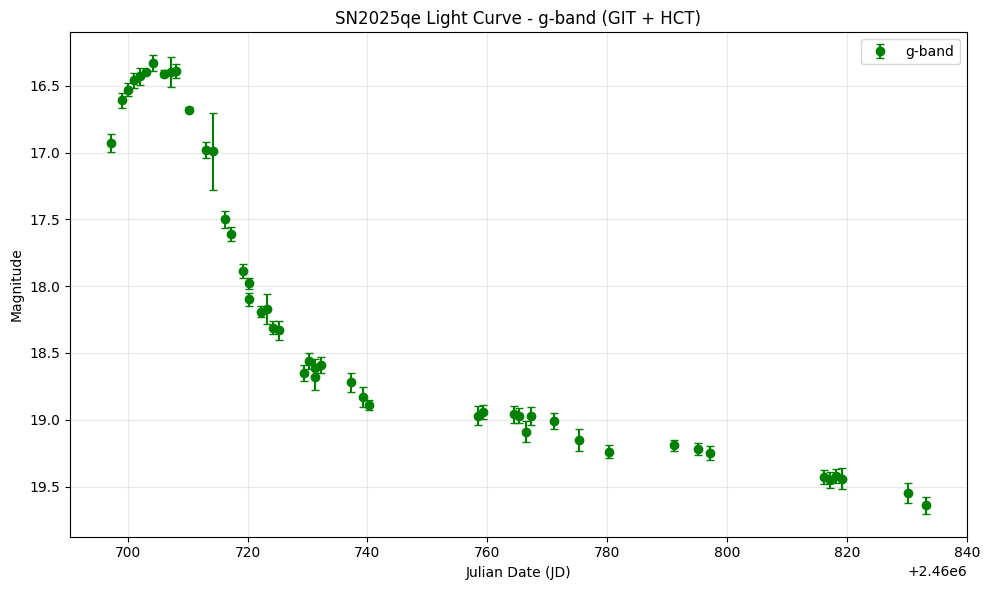

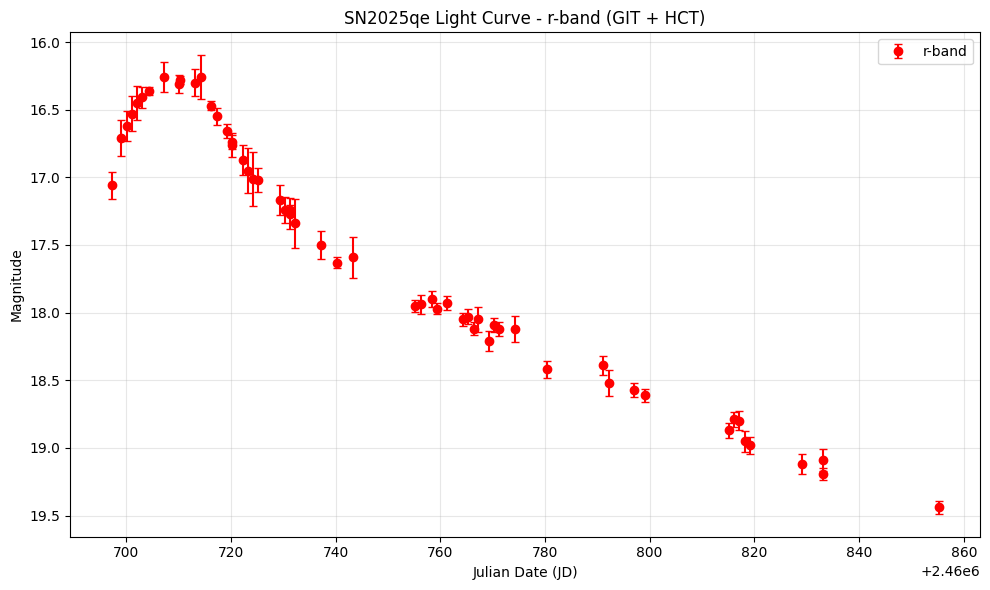

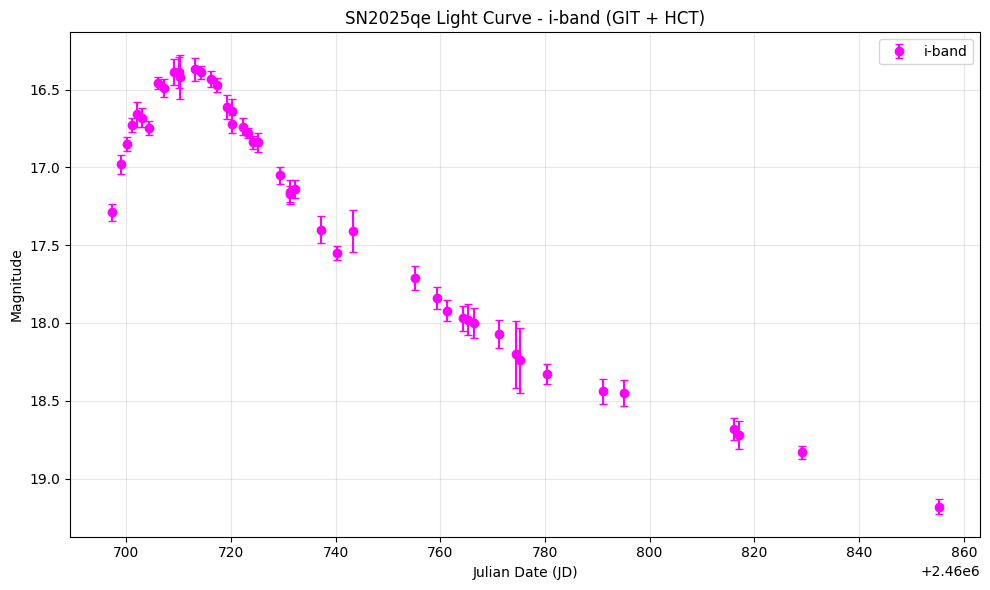

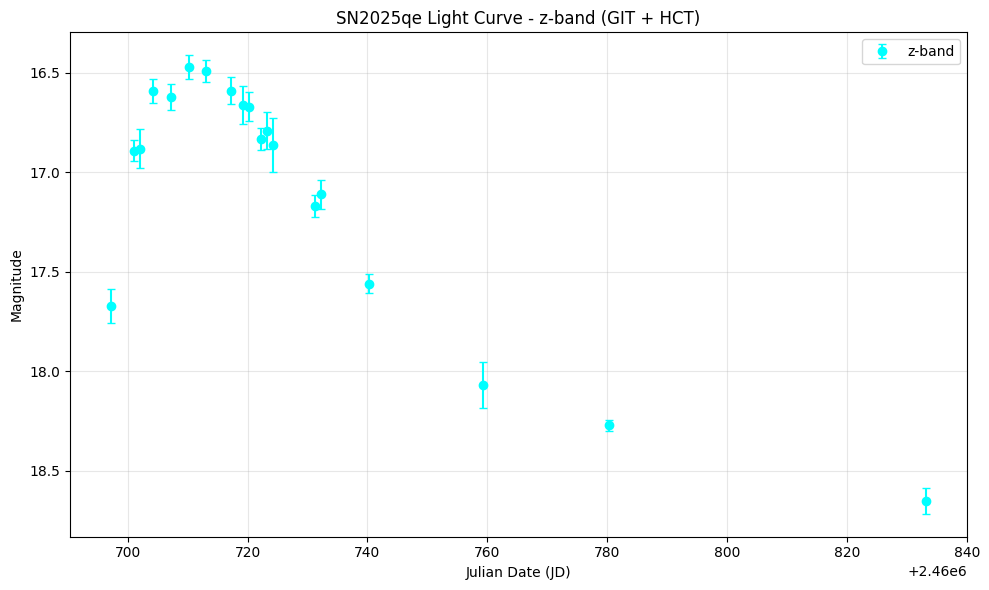

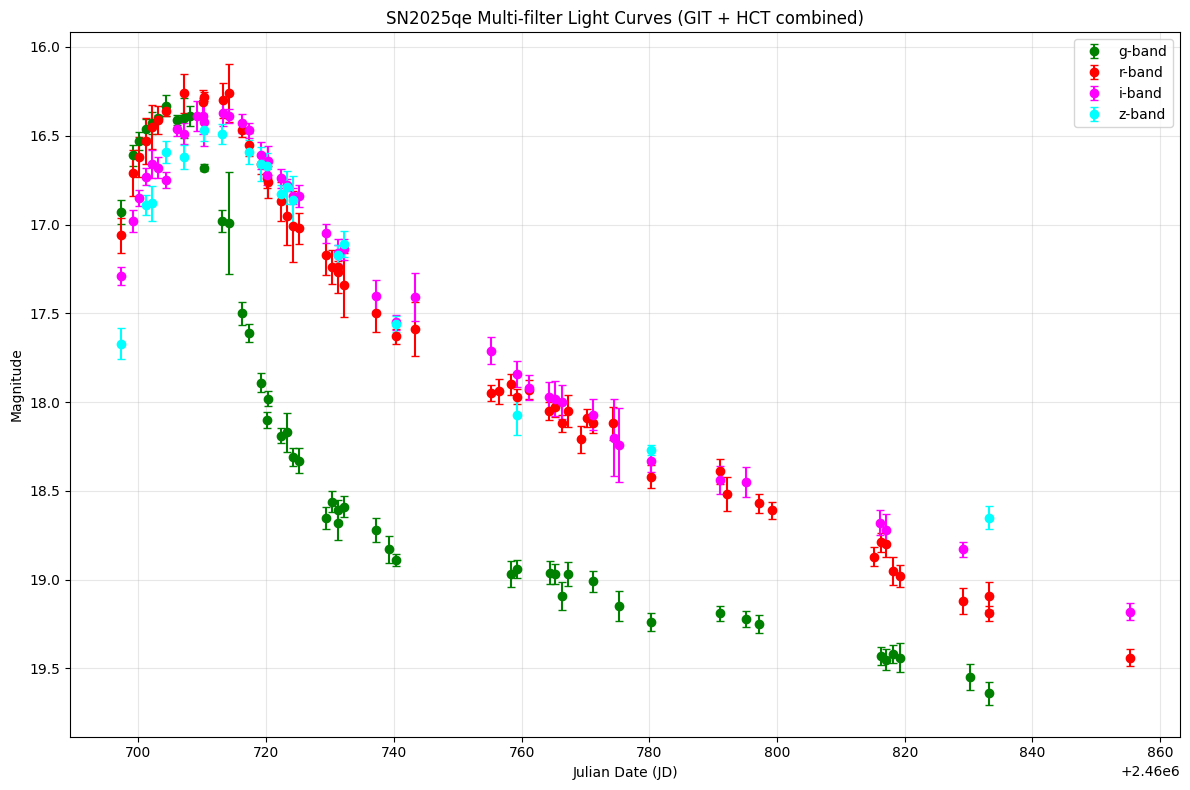

Data Summary:
g-band: 48 detections, mag range 16.33 - 19.64
r-band: 56 detections, mag range 16.26 - 19.44
i-band: 46 detections, mag range 16.37 - 19.18
z-band: 19 detections, mag range 16.47 - 18.65


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your combined CSV file
file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters and their colors (griz standard colors)
filters = ['g', 'r', 'i', 'z']
colors = {'g': 'green', 'r': 'red', 'i': 'magenta', 'z': 'cyan'}

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'e{mag_col}'  # eg, er, ei, ez
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot individual filter light curves
for f in filters:
    plt.figure(figsize=(10, 6))
    valid_jd, mags, errs = get_valid_data(df, f)

    plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                markersize=6, capsize=3, label=f'{f}-band')
    plt.gca().invert_yaxis()  # Magnitude scale reversed
    plt.xlabel('Julian Date (JD)')
    plt.ylabel('Magnitude')
    plt.title(f'SN2025qe Light Curve - {f}-band (GIT + HCT)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot ALL filters on single plot
plt.figure(figsize=(12, 8))
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                markersize=6, capsize=3, label=f'{f}-band')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude')
plt.title('SN2025qe Multi-filter Light Curves (GIT + HCT combined)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Data Summary:")
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    print(f"{f}-band: {len(valid_jd)} detections, mag range {mags.min():.2f} - {mags.max():.2f}")


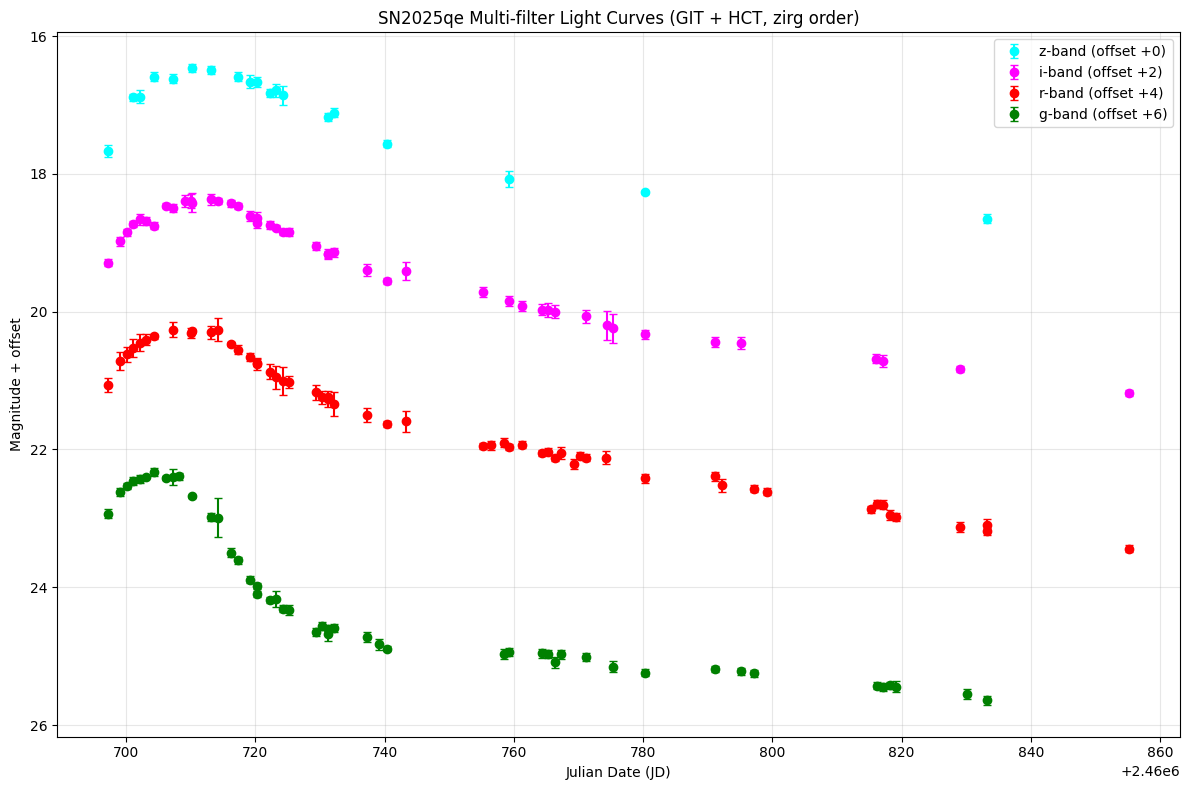

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your combined CSV file
file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters in "zirg" order (z at bottom → g at top) and offsets
filters = ['z', 'i', 'r', 'g']  # Bottom to top order
colors = {'g': 'green', 'r': 'red', 'i': 'magenta', 'z': 'cyan'}
offsets = np.arange(len(filters)) * 2  # Offset by 2 mags each

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'e{mag_col}'  # eg, er, ei, ez
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot multi-filter light curves WITH OFFSETS (zirg order: z bottom → g top)
plt.figure(figsize=(12, 8))
for idx, f in enumerate(filters):  # z=0, i=1, r=2, g=3 → z bottom, g top
    valid_jd, mags, errs = get_valid_data(df, f)
    mask = ~np.isnan(mags)
    y_offset = mags[mask] + offsets[idx]  # z:+0, i:+2, r:+4, g:+6
    yerr_offset = errs[mask]              # Error stays same

    plt.errorbar(valid_jd[mask], y_offset, yerr=yerr_offset,
                fmt='o', color=colors[f], markersize=6, capsize=3,
                label=f'{f}-band (offset +{offsets[idx]})')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude + offset')
plt.title('SN2025qe Multi-filter Light Curves (GIT + HCT, zirg order)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
pip install extinction


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.8/627.8 kB 9.2 MB/s eta 0:00:00


**Photometeric parameters of combined Data**

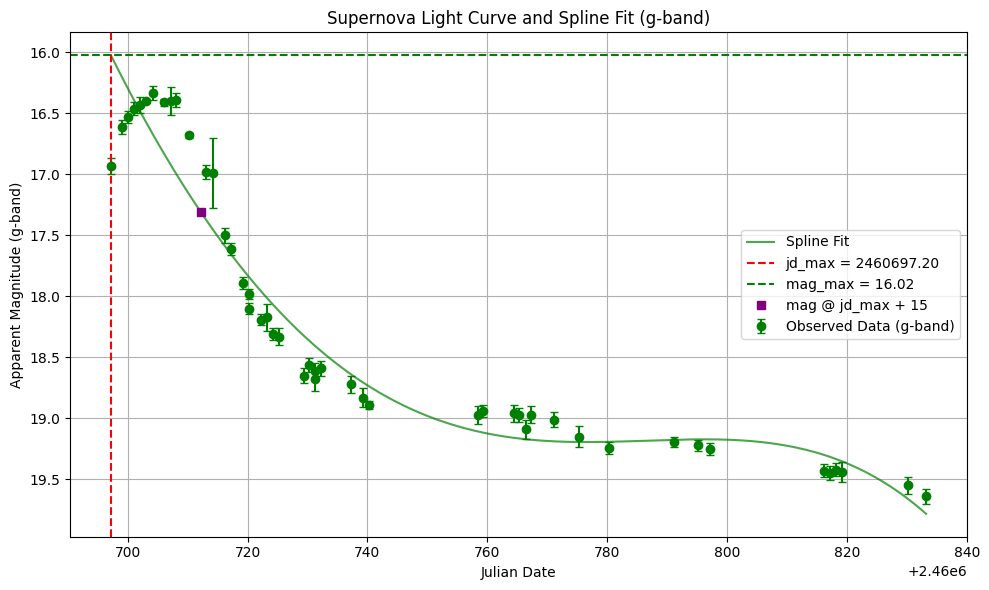

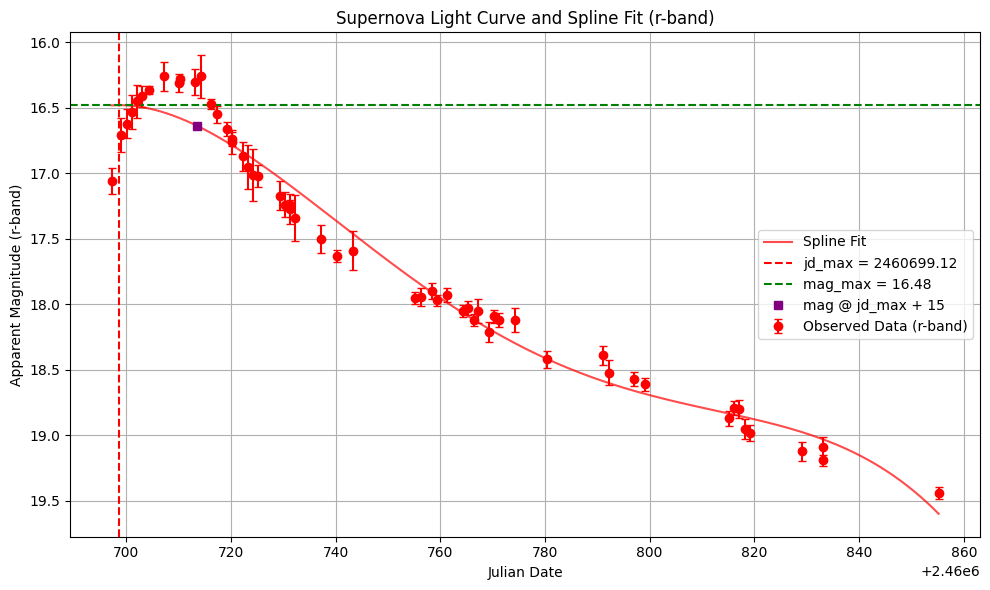

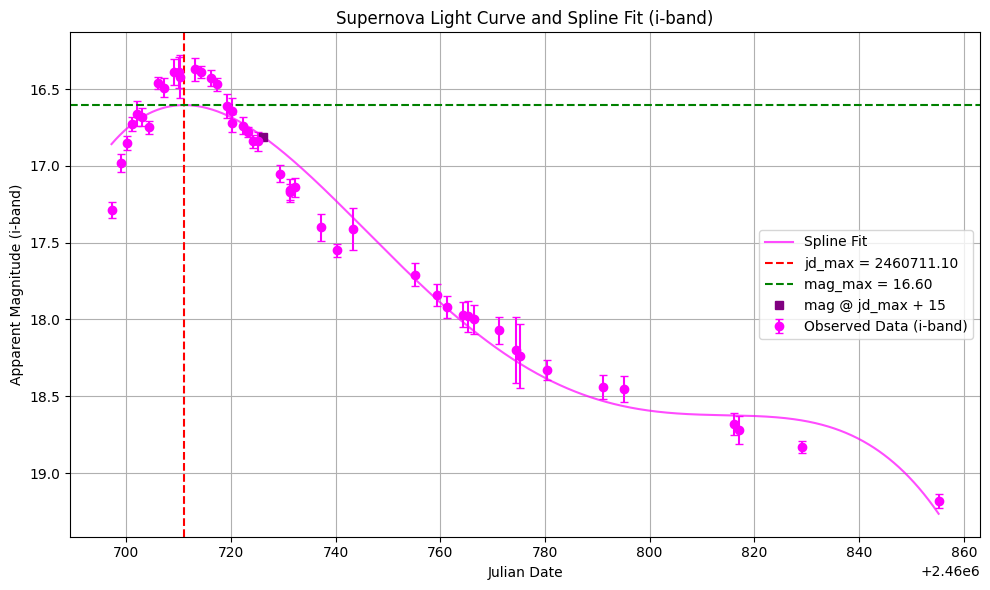

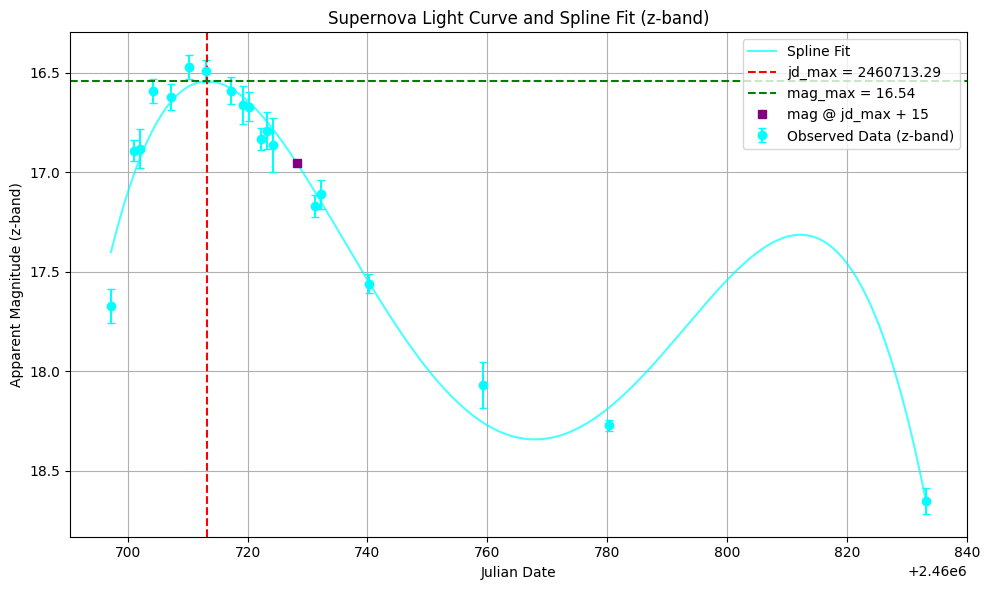


--- Summary of Light Curve Parameters ---

G-band:
  JD of Maximum Brightness (jd_max): 2460697.200 ± 0.000
  Maximum Apparent Magnitude (mag_max): 16.025 ± 0.028
  Maximum Absolute Magnitude (M_max): -16.499 ± 0.153
  Δm15: 1.284 ± 0.033

R-band:
  JD of Maximum Brightness (jd_max): 2460699.124 ± 1.817
  Maximum Apparent Magnitude (mag_max): 16.477 ± 0.043
  Maximum Absolute Magnitude (M_max): -16.027 ± 0.156
  Δm15: 0.165 ± 0.008

I-band:
  JD of Maximum Brightness (jd_max): 2460711.099 ± 0.545
  Maximum Apparent Magnitude (mag_max): 16.604 ± 0.015
  Maximum Absolute Magnitude (M_max): -15.884 ± 0.151
  Δm15: 0.204 ± 0.009

Z-band:
  JD of Maximum Brightness (jd_max): 2460713.292 ± 0.348
  Maximum Apparent Magnitude (mag_max): 16.542 ± 0.027
  Maximum Absolute Magnitude (M_max): -15.936 ± 0.152
  Δm15: 0.413 ± 0.023


,jd_max,jd_max_err,mag_max,mag_max_err,abs_mag,abs_mag_err,delta_m15,delta_m15_err
g,2.460697e+06,4.656613e-09,16.024645,0.028015,-16.499091,0.152594,1.284075,0.032969
r,2.460699e+06,1.816964e+00,16.476649,0.043258,-16.026532,0.156113,0.165468,0.007566
i,2.460711e+06,5.451760e-01,16.603866,0.014970,-15.884385,0.150745,0.204430,0.008839
z,2.460713e+06,3.479516e-01,16.542021,0.027184,-15.935816,0.152443,0.412930,0.023342


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from astropy.stats import sigma_clipped_stats
import extinction

file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters, their central wavelengths (in Angstroms), and colors
filters_info = {
    'g': {'wave': 4816, 'color': 'green', 'label': 'g-band'},
    'r': {'wave': 6139, 'color': 'red', 'label': 'r-band'},
    'i': {'wave': 7480, 'color': 'magenta', 'label': 'i-band'},
    'z': {'wave': 8910, 'color': 'cyan', 'label': 'z-band'}
}

# Astrophysical parameters for absolute magnitude calculation
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

results = {}

for f, info in filters_info.items():
    mag_col = f
    err_col = f'e{f}'

    # Filter out rows with NaN magnitudes or errors for the current band
    valid_data = df.dropna(subset=[mag_col, err_col]).copy()
    if valid_data.empty:
        print(f"No valid data for {f}-band. Skipping.")
        continue

    jd = valid_data['JD']
    mag = valid_data[mag_col]
    mag_err = valid_data[err_col]

    # Sort data by JD before spline fitting
    sort_idx = jd.argsort()
    jd = jd.iloc[sort_idx]
    mag = mag.iloc[sort_idx]
    mag_err = mag_err.iloc[sort_idx]

    # Ensure there are enough data points for spline fitting
    if len(jd) < 5: # UnivariateSpline needs at least k+1 points, k=4, so at least 5 points
        print(f"Not enough data points for {f}-band to perform spline fit. Skipping.")
        continue

    # --- Fit initial spline ---
    # s is a smoothing factor, adjust if spline is too wiggly or too smooth
    spline = UnivariateSpline(jd, mag, k=4, s=0.1 * len(jd))
    fine_jd = np.linspace(jd.min(), jd.max(), 1000)
    fine_mag = spline(fine_jd)

    # Find jd_max and mag_max from the spline
    jd_max = fine_jd[np.argmin(fine_mag)]
    mag_max = np.min(fine_mag)

    # Calculate initial delta_m15
    try:
        delta_m15 = spline(jd_max + 15) - mag_max
    except ValueError: # Handle cases where jd_max + 15 is outside the spline range
        delta_m15 = np.nan

    # --- Monte Carlo Simulation ---
    n_iter = 1000
    jd_max_sim = []
    mag_max_sim = []
    delta_m15_sim = []

    for i in range(n_iter):
        mag_sim = mag + np.random.normal(0, mag_err)
        spline_sim = UnivariateSpline(jd, mag_sim, k=4, s=0.1 * len(jd))
        fine_mag_sim = spline_sim(fine_jd)

        jd_peak_sim = fine_jd[np.argmin(fine_mag_sim)]
        mag_peak_sim = np.min(fine_mag_sim)

        jd_max_sim.append(jd_peak_sim)
        mag_max_sim.append(mag_peak_sim)

        try:
            mag_plus_15_sim = spline_sim(jd_peak_sim + 15)
            delta_m15_sim.append(mag_plus_15_sim - mag_peak_sim)
        except ValueError:
            delta_m15_sim.append(np.nan)

    # Convert to numpy arrays and clean NaNs for sigma_clipped_stats
    jd_max_sim = np.array(jd_max_sim)
    mag_max_sim = np.array(mag_max_sim)
    delta_m15_sim = np.array(delta_m15_sim)

    jd_max_sim = jd_max_sim[~np.isnan(jd_max_sim)]
    mag_max_sim = mag_max_sim[~np.isnan(mag_max_sim)]
    delta_m15_sim = delta_m15_sim[~np.isnan(delta_m15_sim)]

    # --- Sigma-Clipped Stats ---
    # Ensure enough data points for sigma_clipped_stats
    if len(jd_max_sim) > 0: # Check if array is not empty after NaN removal
        jd_max_mean, _, jd_max_std = sigma_clipped_stats(jd_max_sim)
    else:
        jd_max_mean, jd_max_std = np.nan, np.nan

    if len(mag_max_sim) > 0:
        mag_max_mean, _, mag_max_std = sigma_clipped_stats(mag_max_sim)
    else:
        mag_max_mean, mag_max_std = np.nan, np.nan

    if len(delta_m15_sim) > 0:
        delta_m15_mean, _, delta_m15_std = sigma_clipped_stats(delta_m15_sim)
    else:
        delta_m15_mean, delta_m15_std = np.nan, np.nan

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.errorbar(jd, mag, yerr=mag_err, fmt='o', color=info['color'], label=f'Observed Data ({info["label"]})', capsize=3)
    plt.plot(fine_jd, fine_mag, '-', color=info['color'], alpha=0.7, label='Spline Fit')
    plt.axvline(jd_max, color='r', linestyle='--', label=f'jd_max = {jd_max_mean:.2f}')
    plt.axhline(mag_max, color='g', linestyle='--', label=f'mag_max = {mag_max_mean:.2f}')

    # Mark jd_max + 15
    try:
        mag_15 = spline(jd_max + 15)
        plt.plot(jd_max + 15, mag_15, 's', color='purple', label='mag @ jd_max + 15')
    except ValueError:
        pass # Do nothing if outside range

    plt.gca().invert_yaxis()
    plt.xlabel('Julian Date')
    plt.ylabel(f'Apparent Magnitude ({info["label"]})')
    plt.title(f'Supernova Light Curve and Spline Fit ({info["label"]})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate Absolute Magnitude
    Av = 3.1 * E_BV
    wave_angstrom = np.array([info['wave']])
    ext = extinction.fm07(wave_angstrom, Av)[0]

    abs_mag_max = mag_max_mean - modulus - ext
    abs_mag_max_err = np.sqrt((mag_max_std)**2 + (modulus_err)**2)

    # Store results
    results[f] = {
        'jd_max': jd_max_mean,
        'jd_max_err': jd_max_std,
        'mag_max': mag_max_mean,
        'mag_max_err': mag_max_std,
        'abs_mag': abs_mag_max,
        'abs_mag_err': abs_mag_max_err,
        'delta_m15': delta_m15_mean,
        'delta_m15_err': delta_m15_std
    }

# Create a DataFrame from the results for better presentation
summary_df = pd.DataFrame.from_dict(results, orient='index')

# --- Output Results ---
print("\n--- Summary of Light Curve Parameters ---")
for f, row in summary_df.iterrows():
    print(f"\n{f.upper()}-band:")
    print(f"  JD of Maximum Brightness (jd_max): {row['jd_max']:.3f} \u00B1 {row['jd_max_err']:.3f}")
    print(f"  Maximum Apparent Magnitude (mag_max): {row['mag_max']:.3f} \u00B1 {row['mag_max_err']:.3f}")
    print(f"  Maximum Absolute Magnitude (M_max): {row['abs_mag']:.3f} \u00B1 {row['abs_mag_err']:.3f}")
    print(f"  \u0394m15: {row['delta_m15']:.3f} \u00B1 {row['delta_m15_err']:.3f}")

display(summary_df)


**UVOT Data**

Available columns: ['JD', 'U', 'U_Err', 'B', 'B_Err', 'V', 'V_Err', 'W1', 'W1_Err', 'M2', 'M2_Err', 'W2', 'W2_Err']

First 3 rows:
          JD        U   U_Err        B   B_Err        V   V_Err       W1  \
0  2460694.6  16.9919  0.1034  18.0909  0.1659    INDEF   INDEF  17.7922   
1  2460697.2  16.3307  0.0712  16.9586  0.0737   17.124  0.1609   17.414   
2  2460699.0  16.1952  0.0995   16.834   0.106  16.8916  0.2152  17.6214   

   W1_Err       M2 M2_Err     W2 W2_Err  
0   0.183    INDEF  INDEF  INDEF  INDEF  
1  0.1448  18.6721  0.178  INDEF  INDEF  
2  0.2059    INDEF  INDEF  INDEF  INDEF  


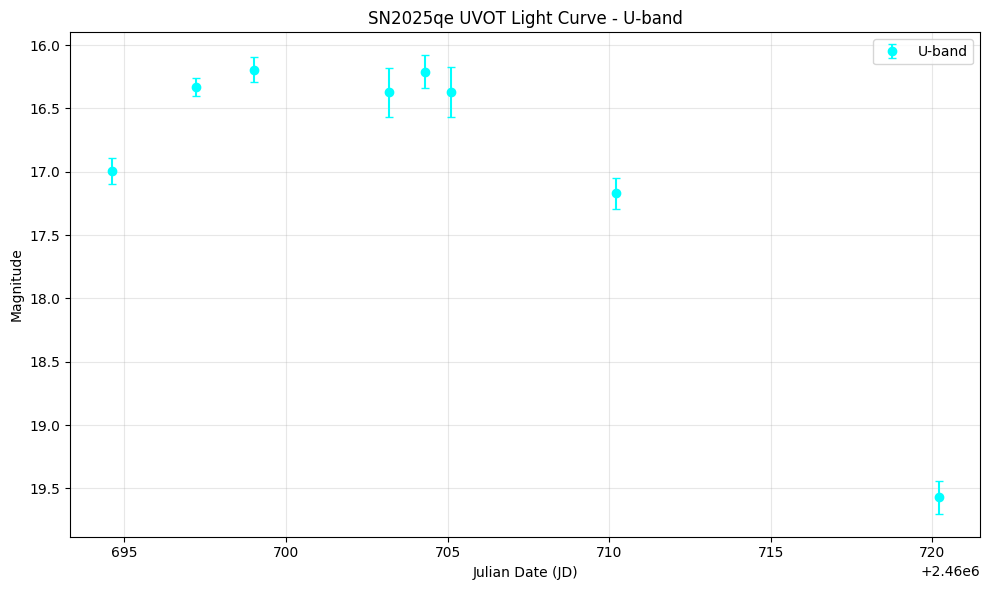

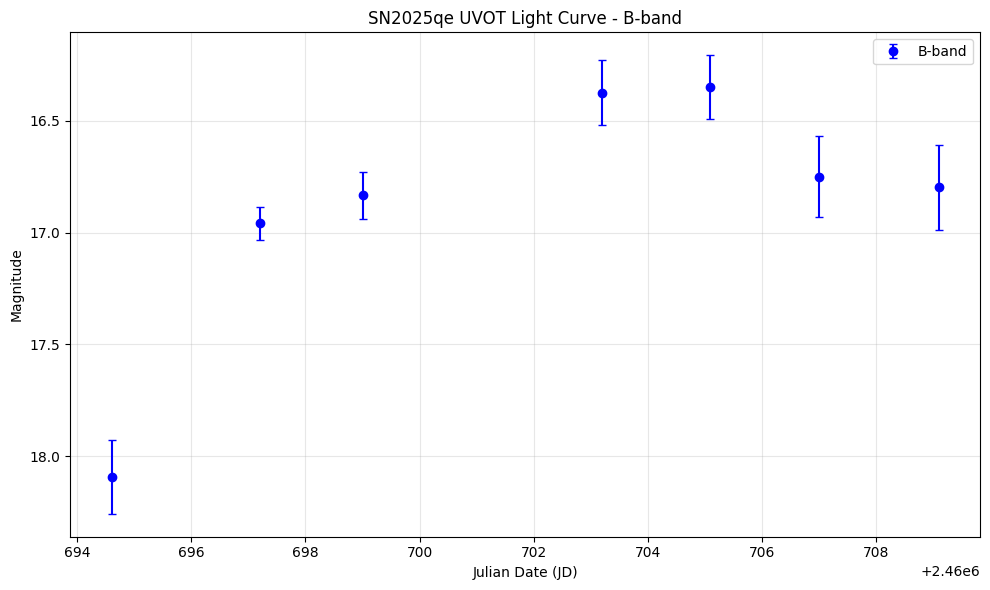

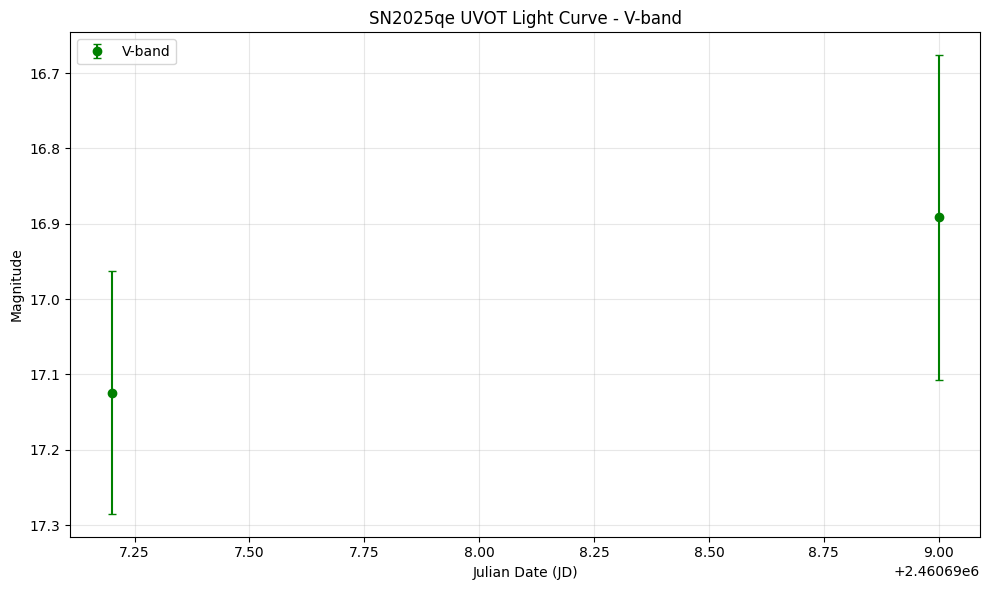

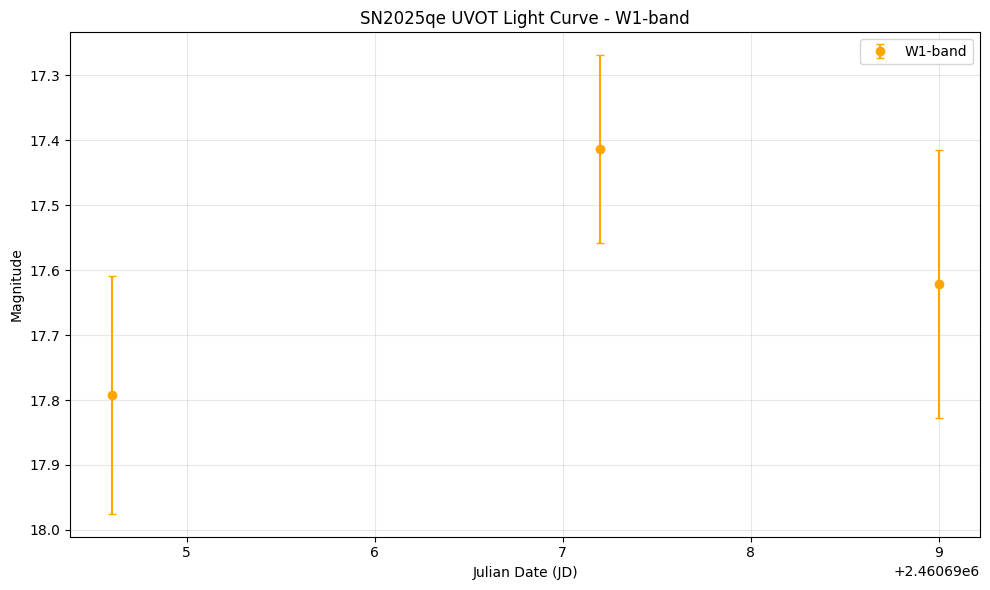

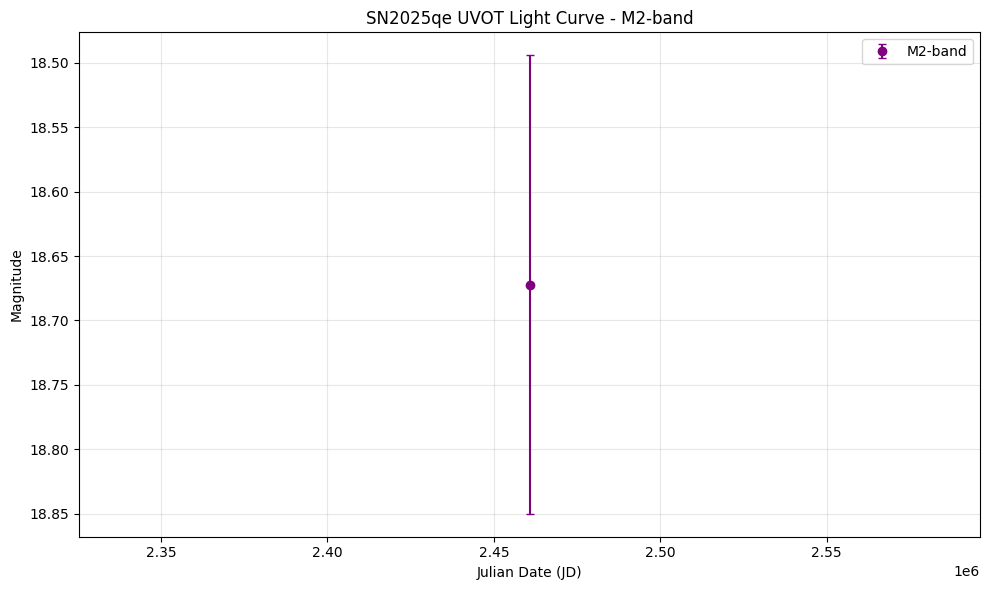

No valid data for W2-band


<Figure size 1000x600 with 0 Axes>

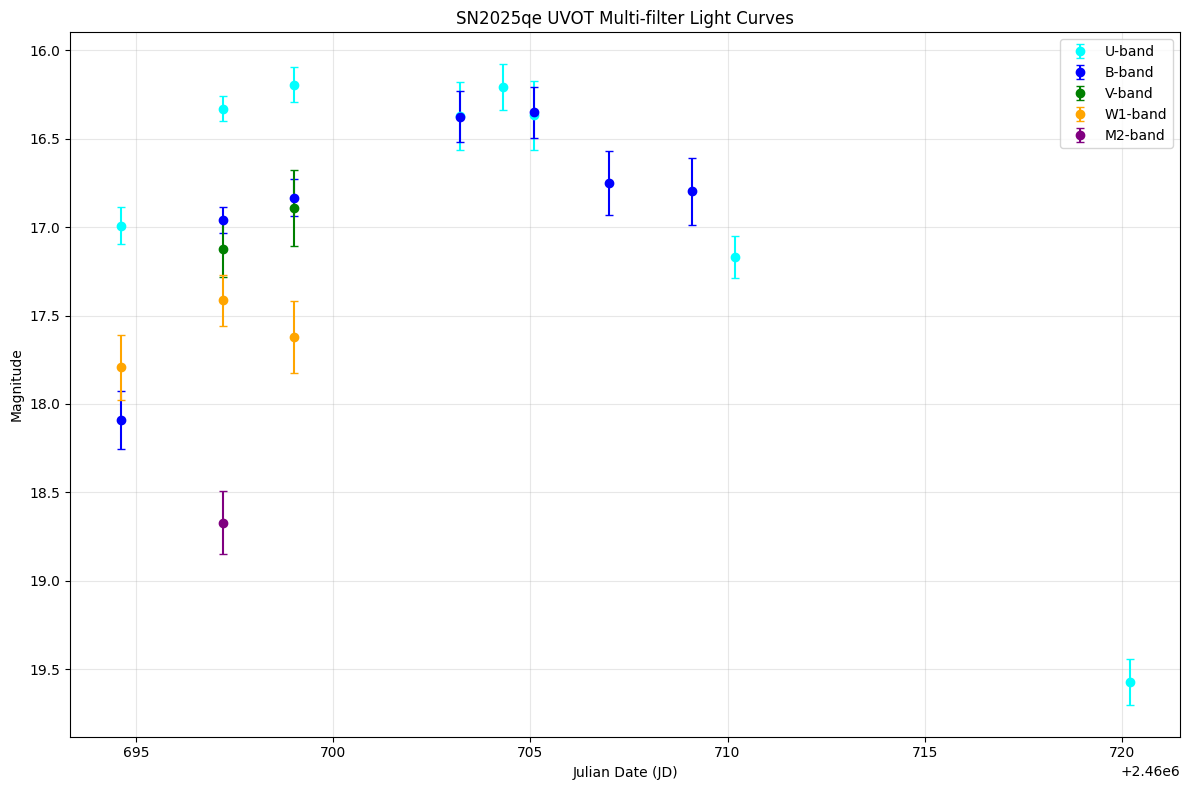


UVOT Data Summary:
U-band: 8 detections, mag range 16.20 - 19.57
B-band: 7 detections, mag range 16.35 - 18.09
V-band: 2 detections, mag range 16.89 - 17.12
W1-band: 3 detections, mag range 17.41 - 17.79
M2-band: 1 detections, mag range 18.67 - 18.67
W2-band: No valid data


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# FIXED: Use sep=r'\s+' (modern replacement for delim_whitespace)
file_path = '/content/drive/MyDrive/2025qe/UVOT_Photometry_Table.dat'
df = pd.read_csv(file_path, sep=r'\s+')  # Fixed whitespace parsing

# DEBUG: Check columns first
print("Available columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

# Replace INDEF with NaN and convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define UVOT filters and colors
filters = ['U', 'B', 'V', 'W1', 'M2', 'W2']
colors = {'U': 'cyan', 'B': 'blue', 'V': 'green', 'W1': 'orange',
          'M2': 'purple', 'W2': 'magenta'}

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'{filter_name}_Err'
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot individual filter light curves
for f in filters:
    plt.figure(figsize=(10, 6))
    valid_jd, mags, errs = get_valid_data(df, f)

    if len(valid_jd) > 0:
        plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                    markersize=6, capsize=3, label=f'{f}-band')
        plt.gca().invert_yaxis()
        plt.xlabel('Julian Date (JD)')
        plt.ylabel('Magnitude')
        plt.title(f'SN2025qe UVOT Light Curve - {f}-band')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid data for {f}-band")

# Plot ALL filters on single plot
plt.figure(figsize=(12, 8))
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    if len(valid_jd) > 0:
        plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                    markersize=6, capsize=3, label=f'{f}-band')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude')
plt.title('SN2025qe UVOT Multi-filter Light Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nUVOT Data Summary:")
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    if len(valid_jd) > 0:
        print(f"{f}-band: {len(valid_jd)} detections, mag range {mags.min():.2f} - {mags.max():.2f}")
    else:
        print(f"{f}-band: No valid data")


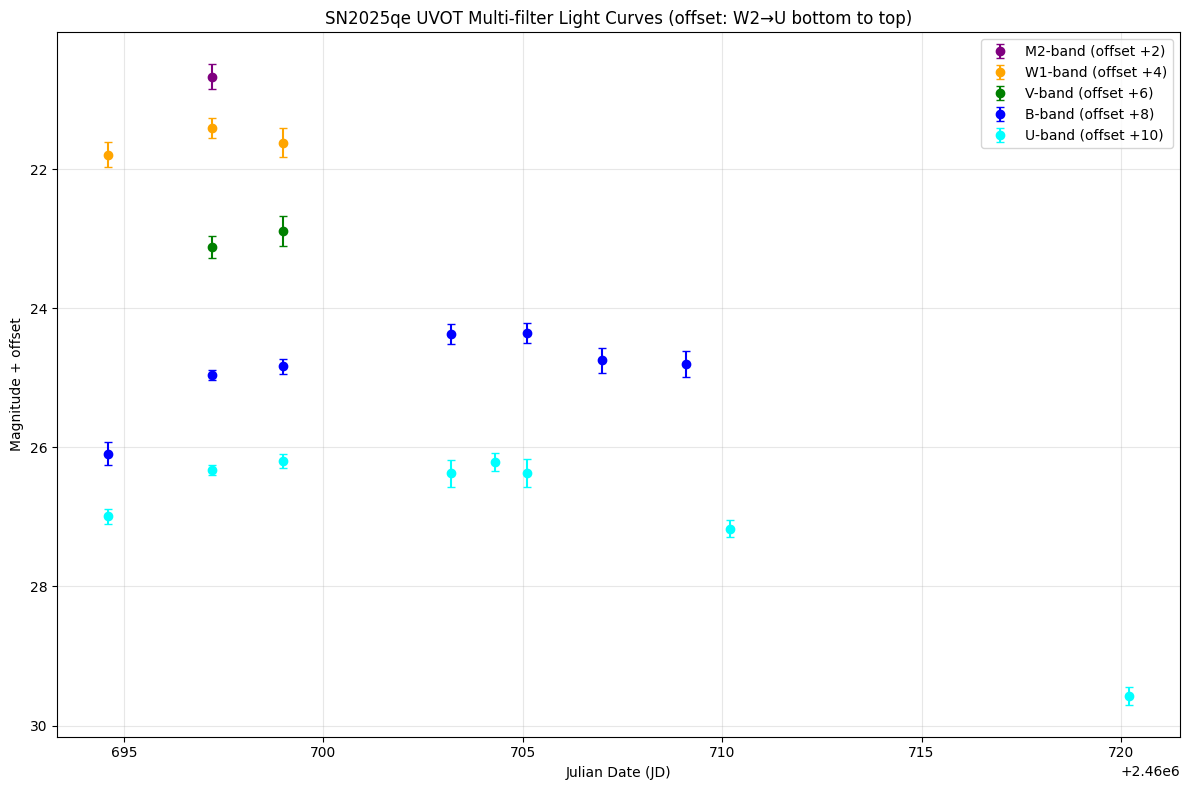

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load UVOT photometry data
file_path = '/content/drive/MyDrive/2025qe/UVOT_Photometry_Table.dat'
df = pd.read_csv(file_path, sep=r'\s+')

# Replace INDEF with NaN and convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define UVOT filters in desired order and offsets
filters = ['W2', 'M2', 'W1', 'V', 'B', 'U']  # Bottom to top: UV to optical
colors = {'U': 'cyan', 'B': 'blue', 'V': 'green', 'W1': 'orange',
          'M2': 'purple', 'W2': 'magenta'}
offsets = np.arange(len(filters)) * 2  # Offset by 2 mags each

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'{filter_name}_Err'
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot multi-filter light curves WITH OFFSETS (W2 bottom → U top)
plt.figure(figsize=(12, 8))
for idx, f in enumerate(filters):  # W2=0, M2=1, W1=2, V=3, B=4, U=5
    valid_jd, mags, errs = get_valid_data(df, f)
    mask = ~np.isnan(mags)
    if len(valid_jd[mask]) > 0:
        y_offset = mags[mask] + offsets[idx]  # W2:+0, U:+10 (top)
        yerr_offset = errs[mask]

        plt.errorbar(valid_jd[mask], y_offset, yerr=yerr_offset,
                    fmt='o', color=colors[f], markersize=6, capsize=3,
                    label=f'{f}-band (offset +{offsets[idx]})')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude + offset')
plt.title('SN2025qe UVOT Multi-filter Light Curves (offset: W2→U bottom to top)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


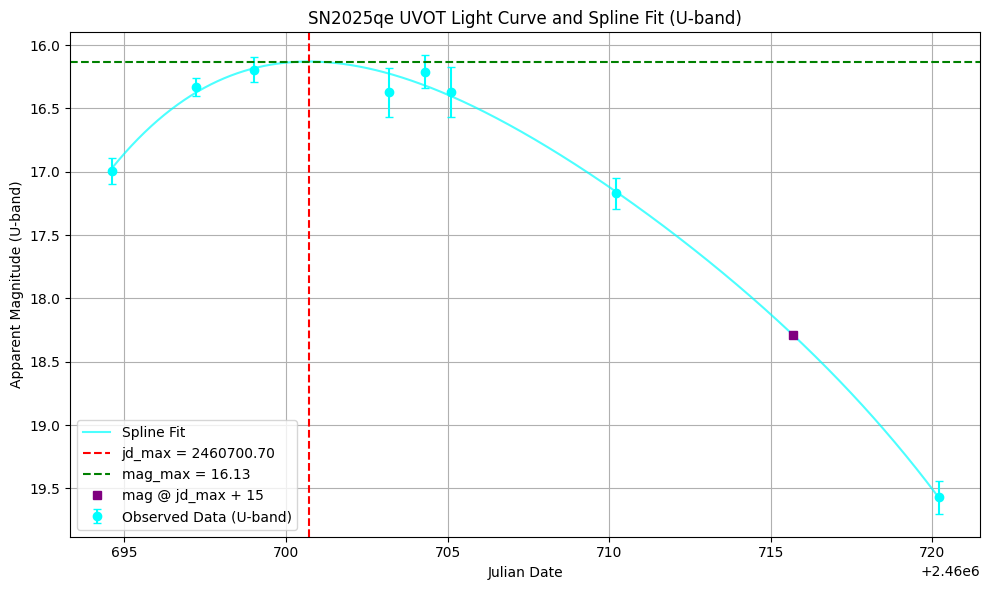

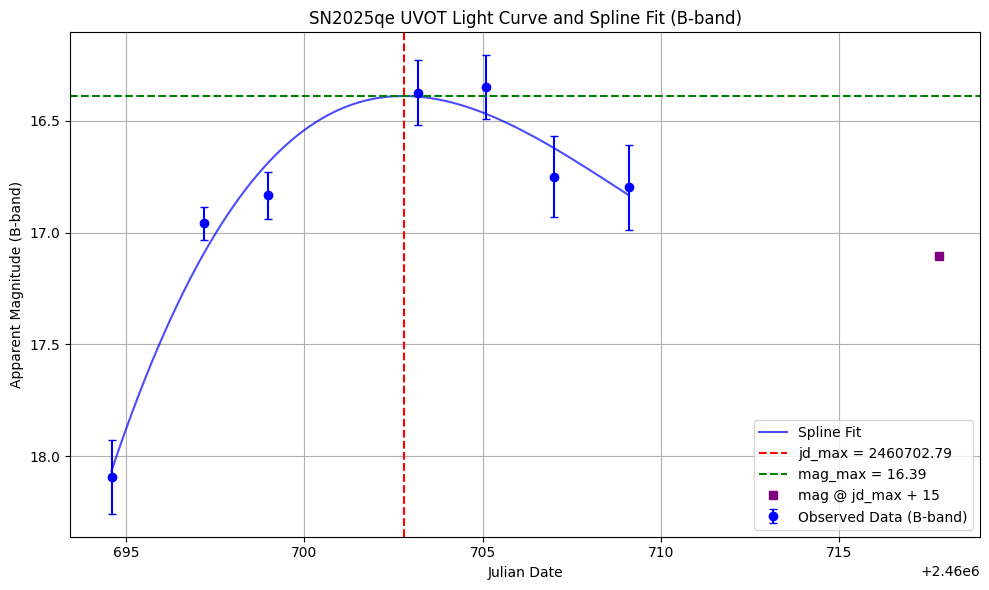

Not enough data points for V-band to perform spline fit. Skipping.
Not enough data points for W1-band to perform spline fit. Skipping.
Not enough data points for M2-band to perform spline fit. Skipping.
No valid data for W2-band. Skipping.

--- SN2025qe UVOT Light Curve Parameters ---

U-band:
  JD of Maximum Brightness (jd_max): 2460700.715 ± 0.684
  Maximum Apparent Magnitude (mag_max): 16.121 ± 0.072
  Maximum Absolute Magnitude (M_max): -16.428 ± 0.166
  Δm15: 2.183 ± 0.432

B-band:
  JD of Maximum Brightness (jd_max): 2460703.243 ± 1.361
  Maximum Apparent Magnitude (mag_max): 16.357 ± 0.108
  Maximum Absolute Magnitude (M_max): -16.174 ± 0.185
  Δm15: 2.546 ± 13.868

Summary Table:


,jd_max,jd_max_err,mag_max,mag_max_err,abs_mag,abs_mag_err,delta_m15,delta_m15_err
U,2.460701e+06,0.683912,16.121249,0.071755,-16.427592,0.166279,2.182963,0.431778
B,2.460703e+06,1.360740,16.357175,0.108284,-16.174109,0.185001,2.546190,13.868104


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from astropy.stats import sigma_clipped_stats
import extinction

# Load UVOT photometry data
file_path = '/content/drive/MyDrive/2025qe/UVOT_Photometry_Table.dat'
df = pd.read_csv(file_path, sep=r'\s+')

# Convert INDEF to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define UVOT filters, their central wavelengths (in Angstroms), and colors
filters_info = {
    'U': {'wave': 3465, 'color': 'cyan', 'label': 'U-band'},
    'B': {'wave': 4392, 'color': 'blue', 'label': 'B-band'},
    'V': {'wave': 5468, 'color': 'green', 'label': 'V-band'},
    'W1': {'wave': 2600, 'color': 'orange', 'label': 'UVW1-band'},
    'M2': {'wave': 2246, 'color': 'purple', 'label': 'u-band'},
    'W2': {'wave': 1930, 'color': 'magenta', 'label': 'UVW2-band'}
}

# Astrophysical parameters for absolute magnitude calculation
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

results = {}

for f, info in filters_info.items():
    mag_col = f
    err_col = f'{f}_Err'

    # Filter out rows with NaN magnitudes or errors for the current band
    valid_data = df.dropna(subset=[mag_col, err_col]).copy()
    if valid_data.empty:
        print(f"No valid data for {f}-band. Skipping.")
        continue

    jd = valid_data['JD']
    mag = valid_data[mag_col]
    mag_err = valid_data[err_col]

    # Sort data by JD before spline fitting
    sort_idx = jd.argsort()
    jd = jd.iloc[sort_idx]
    mag = mag.iloc[sort_idx]
    mag_err = mag_err.iloc[sort_idx]

    # Ensure there are enough data points for spline fitting
    if len(jd) < 5:
        print(f"Not enough data points for {f}-band to perform spline fit. Skipping.")
        continue

    # --- Fit initial spline ---
    spline = UnivariateSpline(jd, mag, k=4, s=0.1 * len(jd))
    fine_jd = np.linspace(jd.min(), jd.max(), 1000)
    fine_mag = spline(fine_jd)

    # Find jd_max and mag_max from the spline
    jd_max = fine_jd[np.argmin(fine_mag)]
    mag_max = np.min(fine_mag)

    # Calculate initial delta_m15
    try:
        delta_m15 = spline(jd_max + 15) - mag_max
    except ValueError:
        delta_m15 = np.nan

    # --- Monte Carlo Simulation ---
    n_iter = 100000
    jd_max_sim = []
    mag_max_sim = []
    delta_m15_sim = []

    for i in range(n_iter):
        mag_sim = mag + np.random.normal(0, mag_err)
        spline_sim = UnivariateSpline(jd, mag_sim, k=4, s=0.1 * len(jd))
        fine_mag_sim = spline_sim(fine_jd)

        jd_peak_sim = fine_jd[np.argmin(fine_mag_sim)]
        mag_peak_sim = np.min(fine_mag_sim)

        jd_max_sim.append(jd_peak_sim)
        mag_max_sim.append(mag_peak_sim)

        try:
            mag_plus_15_sim = spline_sim(jd_peak_sim + 15)
            delta_m15_sim.append(mag_plus_15_sim - mag_peak_sim)
        except ValueError:
            delta_m15_sim.append(np.nan)

    # Convert to numpy arrays and clean NaNs
    jd_max_sim = np.array(jd_max_sim)
    mag_max_sim = np.array(mag_max_sim)
    delta_m15_sim = np.array(delta_m15_sim)

    jd_max_sim = jd_max_sim[~np.isnan(jd_max_sim)]
    mag_max_sim = mag_max_sim[~np.isnan(mag_max_sim)]
    delta_m15_sim = delta_m15_sim[~np.isnan(delta_m15_sim)]

    # --- Sigma-Clipped Stats ---
    if len(jd_max_sim) > 0:
        jd_max_mean, _, jd_max_std = sigma_clipped_stats(jd_max_sim)
    else:
        jd_max_mean, jd_max_std = np.nan, np.nan

    if len(mag_max_sim) > 0:
        mag_max_mean, _, mag_max_std = sigma_clipped_stats(mag_max_sim)
    else:
        mag_max_mean, mag_max_std = np.nan, np.nan

    if len(delta_m15_sim) > 0:
        delta_m15_mean, _, delta_m15_std = sigma_clipped_stats(delta_m15_sim)
    else:
        delta_m15_mean, delta_m15_std = np.nan, np.nan

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.errorbar(jd, mag, yerr=mag_err, fmt='o', color=info['color'],
                label=f'Observed Data ({info["label"]})', capsize=3)
    plt.plot(fine_jd, fine_mag, '-', color=info['color'], alpha=0.7, label='Spline Fit')
    plt.axvline(jd_max, color='r', linestyle='--', label=f'jd_max = {jd_max:.2f}')
    plt.axhline(mag_max, color='g', linestyle='--', label=f'mag_max = {mag_max:.2f}')

    # Mark jd_max + 15
    try:
        mag_15 = spline(jd_max + 15)
        plt.plot(jd_max + 15, mag_15, 's', color='purple', label='mag @ jd_max + 15')
    except ValueError:
        pass

    plt.gca().invert_yaxis()
    plt.xlabel('Julian Date')
    plt.ylabel(f'Apparent Magnitude ({info["label"]})')
    plt.title(f'SN2025qe UVOT Light Curve and Spline Fit ({info["label"]})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate Absolute Magnitude
    Av = 3.1 * E_BV
    wave_angstrom = np.array([info['wave']])
    ext = extinction.fm07(wave_angstrom, Av)[0]

    abs_mag_max = mag_max_mean - modulus - ext
    abs_mag_max_err = np.sqrt((mag_max_std)**2 + (modulus_err)**2)

    # Store results
    results[f] = {
        'jd_max': jd_max_mean,
        'jd_max_err': jd_max_std,
        'mag_max': mag_max_mean,
        'mag_max_err': mag_max_std,
        'abs_mag': abs_mag_max,
        'abs_mag_err': abs_mag_max_err,
        'delta_m15': delta_m15_mean,
        'delta_m15_err': delta_m15_std
    }

# Create a DataFrame from the results
summary_df = pd.DataFrame.from_dict(results, orient='index')

# --- Output Results ---
print("\n--- SN2025qe UVOT Light Curve Parameters ---")
for f, row in summary_df.iterrows():
    print(f"\n{f.upper()}-band:")
    print(f"  JD of Maximum Brightness (jd_max): {row['jd_max']:.3f} ± {row['jd_max_err']:.3f}")
    print(f"  Maximum Apparent Magnitude (mag_max): {row['mag_max']:.3f} ± {row['mag_max_err']:.3f}")
    print(f"  Maximum Absolute Magnitude (M_max): {row['abs_mag']:.3f} ± {row['abs_mag_err']:.3f}")
    print(f"  Δm15: {row['delta_m15']:.3f} ± {row['delta_m15_err']:.3f}")

print("\nSummary Table:")
display(summary_df)
